# Generation Visualizer

Visualises *where* the RL agent places synthetic points in PCA space and how that changes across training.

**Sections**
1. Config & data loading
2. Static spatial overview (PC1 × PC2, alpha confidence background)
3. Generation drift across training snapshots
4. Training dynamics (generation radius, DVRL local reward, global reward)
5. Confidence profile of generated points over training
6. Reward alignment diagnostic (DVRL vs global objective)

In [1]:
# ============================================================
# CELL 1 – CONFIG  (edit here)
# ============================================================
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/epigou/cs_9170_project")
sys.path.insert(0, str(PROJECT_ROOT))

# ── Pick a run directory and seed ────────────────────────────
RUNS_ROOT = PROJECT_ROOT / "training_runs"

# List available experiment dirs that contain seed subdirs
def list_runs():
    for d in sorted(RUNS_ROOT.iterdir()):
        if d.is_dir() and any(s.is_dir() and s.name.startswith("seed_") for s in d.iterdir()):
            print(d.name)

list_runs()

BASELINE_gaussian_ot_repair_baseline_otrep_census_a8b46764__G202603111900
BASELINE_gaussian_ot_repair_baseline_otrep_credit_6882b6a2__G202603111900
BASELINE_group_dro_baseline_gdro_census_663e8736__G202603121735
BASELINE_group_dro_baseline_gdro_census_738fc989__G202603111900
BASELINE_group_dro_baseline_gdro_credit_0f79e8fe__G202603121736
BASELINE_group_dro_baseline_gdro_credit_153d34a0__G202603111900
SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_97f273d4
SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603121842_acafe162
SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603131643_0520d348
SPECv3_census_ablation_global_full_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_2f9e695b
SPECv3_census_ablation_global_hard_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_64d2ac98
SPECv3_censu

In [ ]:
# ── Paste the run name and seed you want to inspect ──────────
RUN_NAME = "SPECv17a_census_rl_bias010_EP1000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG..."
SEED     = 42

# Derived paths
RUN_DIR  = RUNS_ROOT / RUN_NAME
SEED_DIR = RUN_DIR / f"seed_{SEED}"
assert SEED_DIR.exists(), f"Not found: {SEED_DIR}"

In [ ]:
# ============================================================
# CELL 2 – LOAD DATA AND ALPHA MODEL
# ============================================================
import json
import numpy as np
import pandas as pd
import torch

from dataset import Dataset
from agents.ffnn_agent2 import FFNNAgent
import reward_helpers as rh

# ── Meta ─────────────────────────────────────────────────────
with open(SEED_DIR / "meta.json") as f:
    meta = json.load(f)
with open(SEED_DIR / "ffnn_meta.json") as f:
    ffnn_meta = json.load(f)

DATASET_NAME   = meta["dataset_name"]
PCA_COMPONENTS = ffnn_meta["n_pca_components"]
MINORITY_ID    = meta.get("minority_id", 1)
MAJORITY_ID    = meta.get("majority_id", 0)
REAL_DATA_SIZE = meta.get("REAL_DATA_SIZE", 3000)
BIAS_PCT       = meta.get("BIAS_PCT", None)

print(f"Dataset: {DATASET_NAME}  |  PCA dims: {PCA_COMPONENTS}  |  Seed: {SEED}")

# ── Load real data (same seed/split as training) ─────────────
ds = Dataset(
    dataset_name=DATASET_NAME,
    multiclass=meta.get("multiclass", False),
    minority_id=MINORITY_ID,
    majority_id=MAJORITY_ID,
    third_id=None,
    pca_components=PCA_COMPONENTS,
    seed=SEED,
    device="cpu",
    use_pca=True,
)
X_tr, X_val, X_te, y_tr, y_val, y_te = ds.get_data_splits(
    train_size=REAL_DATA_SIZE,
    bias_pct=BIAS_PCT,
    pca_components=PCA_COMPONENTS,
    drop_protected=False,
    protected_cols=ds.protected_attributes,
    bias_val=True,
)
a_train = ds.a_train.numpy()          # protected attribute (0/1)

X_tr_np = X_tr.numpy() if isinstance(X_tr, torch.Tensor) else X_tr
y_tr_np = y_tr.numpy() if isinstance(y_tr, torch.Tensor) else y_tr

print(f"Train: {X_tr_np.shape}  minority={y_tr_np.sum()}  majority={(y_tr_np==0).sum()}")

# ── Load alpha model ──────────────────────────────────────────
alpha = FFNNAgent(
    input_size=PCA_COMPONENTS,
    hidden_sizes=ffnn_meta["hidden_sizes"],
    output_size=ffnn_meta["output_size"],
    type="classification",
    classes=ffnn_meta["classes"],
    device="cpu",
    seed=SEED,
)
alpha.model.load_state_dict(torch.load(SEED_DIR / "alpha_state_dict.pt", map_location="cpu"))
alpha.model.eval()
print("Alpha model loaded.")

# ── Real minority subset (for reference in plots) ─────────────
disadv_mask = (a_train == MINORITY_ID)
pos_mask    = (y_tr_np == 1)
min_pos_mask = disadv_mask & pos_mask   # disadvantaged + positive
print(f"Disadvantaged positive (minority class to synthesise): n={min_pos_mask.sum()}")

In [ ]:
# ============================================================
# CELL 3 – STATIC SPATIAL OVERVIEW  (PC1 × PC2)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load best synthetic
syn_df = pd.read_csv(SEED_DIR / "best_synthetic_phase1_class1.csv")
pca_cols = [f"pca_{i}" for i in range(PCA_COMPONENTS)]
syn_np = syn_df[pca_cols].values

# ── Alpha confidence heatmap on PC1×PC2 grid ─────────────────
def alpha_confidence_grid(alpha_model, X_ref, pc_x=0, pc_y=1, margin=0.5, n=120):
    """Evaluate p_alpha on a 2D grid over pc_x × pc_y; other dims = mean of X_ref."""
    mean_vec = X_ref.mean(axis=0)
    x_min, x_max = X_ref[:, pc_x].min() - margin, X_ref[:, pc_x].max() + margin
    y_min, y_max = X_ref[:, pc_y].min() - margin, X_ref[:, pc_y].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n))
    grid = np.tile(mean_vec, (n * n, 1)).astype(np.float32)
    grid[:, pc_x] = xx.ravel()
    grid[:, pc_y] = yy.ravel()
    with torch.no_grad():
        p = rh.p1_from_agent(alpha_model, torch.tensor(grid)).numpy()
    return xx, yy, p.reshape(n, n), x_min, x_max, y_min, y_max

PC_X, PC_Y = 0, 1   # which PCA dims to plot
print("Computing confidence grid…")
xx, yy, zz, xmn, xmx, ymn, ymx = alpha_confidence_grid(alpha, X_tr_np, pc_x=PC_X, pc_y=PC_Y)

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Confidence background
im = ax.contourf(xx, yy, zz, levels=50, cmap="RdYlGn_r", alpha=0.35, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="p_alpha (P[y=1])")
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=1.5, linestyles="--")

# Real majority
maj_mask = y_tr_np == MAJORITY_ID
ax.scatter(X_tr_np[maj_mask, PC_X], X_tr_np[maj_mask, PC_Y],
           s=8, c="#aaaaaa", alpha=0.25, label="Real majority", zorder=2)
# Real minority (all, not just disadvantaged)
min_mask = y_tr_np == MINORITY_ID
ax.scatter(X_tr_np[min_mask, PC_X], X_tr_np[min_mask, PC_Y],
           s=18, c="#4477CC", alpha=0.40, label=f"Real minority (n={min_mask.sum()})", zorder=3)
# Disadvantaged positive (the scarce group the agent augments)
ax.scatter(X_tr_np[min_pos_mask, PC_X], X_tr_np[min_pos_mask, PC_Y],
           s=50, c="#FF2200", alpha=0.70, marker="x", linewidths=1.5,
           label=f"Disadv. positive — target class (n={min_pos_mask.sum()})", zorder=5)
# Best synthetic
ax.scatter(syn_np[:, PC_X], syn_np[:, PC_Y],
           s=25, c="#FF7700", alpha=0.55, marker="D",
           label=f"Best synthetic (n={len(syn_np)})", zorder=4)

ax.set_xlabel(f"PC{PC_X+1}"); ax.set_ylabel(f"PC{PC_Y+1}")
ax.set_title(f"{DATASET_NAME} — PC{PC_X+1}×PC{PC_Y+1}  |  {RUN_NAME[:60]}…  seed={SEED}", fontsize=9)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(xmn, xmx); ax.set_ylim(ymn, ymx)
plt.tight_layout()
plt.show()
print("Dashed line = alpha decision boundary (p_alpha=0.5).")
print("Orange diamonds should cluster near the boundary in the disadvantaged-positive region.")

In [ ]:
# ============================================================
# CELL 4 – GENERATION DRIFT ACROSS TRAINING SNAPSHOTS
# ============================================================
# Load all saved snapshot files and show how synthetic point cloud evolves.

snap_dir = SEED_DIR / "synthetic_snapshots"
snap_files = sorted(snap_dir.glob("synthetic_ep*_phase1_class1.npz"))

def ep_num(path):
    return int(path.stem.split("_ep")[1].split("_")[0])

all_episodes = np.array([ep_num(f) for f in snap_files])
print(f"Found {len(snap_files)} snapshots: ep {all_episodes.min()} … {all_episodes.max()}")

# ── Choose a subset of episodes to show ──────────────────────
N_PANELS = 6
idx_sel = np.round(np.linspace(0, len(snap_files)-1, N_PANELS)).astype(int)
sel_files = [snap_files[i] for i in idx_sel]
sel_eps   = [ep_num(f) for f in sel_files]

# ── Pre-compute common axis limits ───────────────────────────
MARGIN = 0.8
xlim = (X_tr_np[:, PC_X].min() - MARGIN, X_tr_np[:, PC_X].max() + MARGIN)
ylim = (X_tr_np[:, PC_Y].min() - MARGIN, X_tr_np[:, PC_Y].max() + MARGIN)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
cmap_ep = plt.cm.viridis

for ax, sf, ep in zip(axes.flat, sel_files, sel_eps):
    data = np.load(sf)
    pts  = data["x"]   # shape (N, PCA_COMPONENTS)

    # Background: real data (faint)
    ax.scatter(X_tr_np[maj_mask, PC_X], X_tr_np[maj_mask, PC_Y],
               s=4, c="#cccccc", alpha=0.20, zorder=1)
    ax.scatter(X_tr_np[min_mask, PC_X], X_tr_np[min_mask, PC_Y],
               s=8, c="#99bbee", alpha=0.25, zorder=2)
    # Disadvantaged positive (target group)
    ax.scatter(X_tr_np[min_pos_mask, PC_X], X_tr_np[min_pos_mask, PC_Y],
               s=30, c="red", marker="x", linewidths=1.3, alpha=0.55, zorder=4,
               label="Disadv. pos.")
    # Synthetic at this episode
    color_val = (ep - sel_eps[0]) / max(sel_eps[-1] - sel_eps[0], 1)
    ax.scatter(pts[:, PC_X], pts[:, PC_Y],
               s=12, c=cmap_ep(color_val), alpha=0.50, zorder=3)
    # Decision boundary contour
    ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=0.8, linestyles="--", alpha=0.5)

    ax.set_title(f"Episode {ep}", fontsize=10)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel(f"PC{PC_X+1}"); ax.set_ylabel(f"PC{PC_Y+1}")

fig.suptitle(
    f"{DATASET_NAME}  —  Synthetic point cloud evolution (PC{PC_X+1}×PC{PC_Y+1})  |  seed={SEED}\n"
    "Red × = disadvantaged positive (target class)   |   dashed = alpha decision boundary   |   colour = training progress",
    fontsize=10
)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 5 – TRAINING DYNAMICS
# ============================================================
# Panel 1: Generation radius
# Panel 2: DVRL local reward over training (replaces anchor proximity panel)
# Panel 3: Reward components — local_reward, global_obj

metrics_df = pd.read_csv(SEED_DIR / "metrics.csv")
ep  = metrics_df["episode"].values

# ── Curriculum stage transitions (disabled in v17+, but kept for older runs) ─
stage_col = "align.curriculum_stage"
stage_transitions = []
if stage_col in metrics_df.columns:
    stages = metrics_df[stage_col].values
    for i in range(1, len(stages)):
        if stages[i] != stages[i-1]:
            stage_transitions.append(ep[i])

def add_stage_lines(ax, label_first=True):
    for j, e in enumerate(stage_transitions):
        ax.axvline(e, color="purple", lw=0.8, ls=":", alpha=0.6,
                   label="Curriculum stage" if (j == 0 and label_first) else None)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ── Panel 1: Generation radius ────────────────────────────────
ax = axes[0]
if "extra.diag_gen_radius_mean" in metrics_df.columns:
    ax.plot(ep, metrics_df["extra.diag_gen_radius_mean"], c="steelblue", lw=1.3, label="Gen radius (mean)")
radius_clip = meta.get("radius_clip", None)
if radius_clip:
    ax.axhline(radius_clip, color="red", lw=1.2, ls="--", label=f"radius_clip={radius_clip}")
add_stage_lines(ax)
ax.set_ylabel("L2 radius from origin")
ax.set_title("Generation radius — how far the agent places synthetic points in PCA space")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# ── Panel 2: DVRL local reward over training ──────────────────
ax = axes[1]
has_local = "local.local_reward_mean" in metrics_df.columns

# Phase 1 shading (eps 1–800 by default)
phase_col = "global.phase"
if phase_col in metrics_df.columns:
    p1_mask = metrics_df[phase_col] == 1
    p1_end = ep[p1_mask].max() if p1_mask.any() else 800
else:
    p1_end = 800
ax.axvspan(ep.min(), p1_end, alpha=0.05, color="blue", label="Phase 1 (minority gen)")
ax.axvspan(p1_end, ep.max(), alpha=0.05, color="orange", label="Phase 2 (majority gen)")

if has_local:
    lr = metrics_df["local.local_reward_mean"].values
    # Rolling smooth (window = ~5% of episodes)
    window = max(1, len(lr) // 20)
    smooth = np.convolve(lr, np.ones(window)/window, mode="same")
    ax.plot(ep, lr, c="lightgray", lw=0.8, alpha=0.6, label="DVRL reward (raw)")
    ax.plot(ep, smooth, c="darkorange", lw=1.8, label=f"DVRL reward (smoothed, w={window})")
    # Reference: median across all Phase-1 episodes
    p1_lr = lr[ep <= p1_end]
    if len(p1_lr) > 0:
        median_lr = np.median(p1_lr)
        ax.axhline(median_lr, color="darkorange", lw=1.0, ls="--", alpha=0.7,
                   label=f"Phase-1 median = {median_lr:.3f}")
else:
    ax.text(0.5, 0.5, "local.local_reward_mean column not found\n(column name may differ by spec version)",
            ha="center", va="center", transform=ax.transAxes, fontsize=10)

add_stage_lines(ax, label_first=False)
ax.set_ylabel("DVRL reward  [clamp(BCE(β,x)/ln2, 0, 1)]")
ax.set_title("DVRL local reward — high = beta is uncertain about the synthetic sample (desired in Phase 1)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_ylim(0, 1.05)

# ── Panel 3: Reward components side by side ──────────────────
ax = axes[2]
if has_local:
    ax.plot(ep, metrics_df["local.local_reward_mean"], c="darkorange", lw=1.3, alpha=0.7, label="DVRL local reward (mean)")
if "global.global_obj" in metrics_df.columns:
    ax.plot(ep, metrics_df["global.global_obj"], c="forestgreen", lw=1.3, ls="--", label="Global obj [sigmoid(β better than α)]")
    ax.axhline(0.5, color="black", lw=0.8, ls=":", alpha=0.5, label="Global deadzone threshold")
add_stage_lines(ax, label_first=False)
ax.set_xlabel("Episode"); ax.set_ylabel("Reward")
ax.set_title("Reward components — DVRL (local) and global objective over training")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.suptitle(
    f"{DATASET_NAME}  —  Training dynamics  |  {RUN_NAME[:70]}…  seed={SEED}",
    fontsize=9
)
plt.tight_layout()
plt.show()

Computing p_alpha for all snapshots (may take ~10s)…


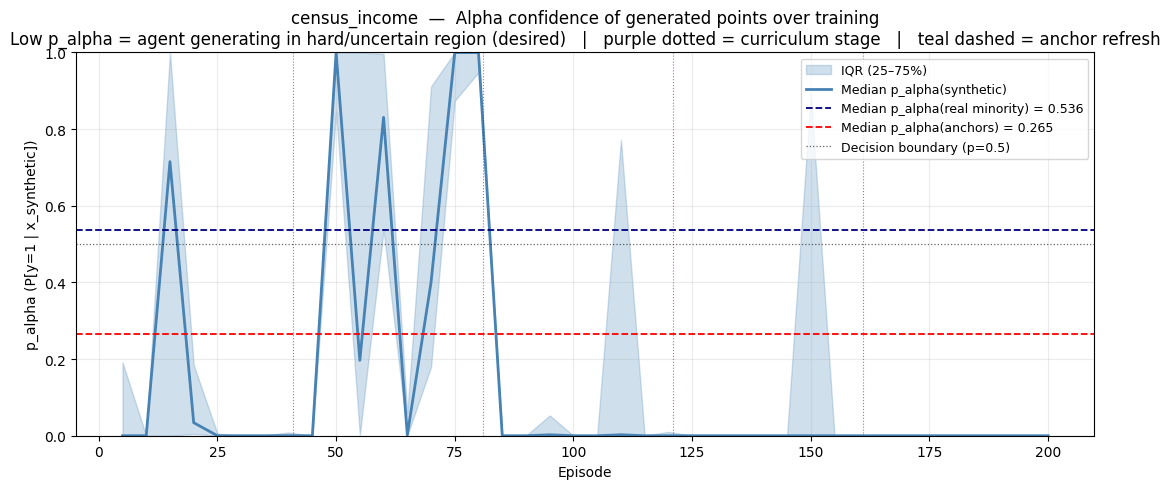

In [7]:
# ============================================================
# CELL 6 – CONFIDENCE PROFILE OF GENERATED POINTS OVER TRAINING
# ============================================================
# For each snapshot, compute p_alpha(x) for every synthetic point.
# Plot the median + IQR over training.
# Goal: low p_alpha = near-boundary / hard region = what we want.

print("Computing p_alpha for all snapshots (may take ~10s)…")

snap_ep_list, p_med_list, p_q25_list, p_q75_list = [], [], [], []

for sf in snap_files:
    ep_n = ep_num(sf)
    data = np.load(sf)
    pts  = data["x"]   # shape (N, PCA_COMPONENTS)
    with torch.no_grad():
        p = rh.p1_from_agent(alpha, torch.tensor(pts.astype(np.float32))).numpy()
    snap_ep_list.append(ep_n)
    p_med_list.append(np.median(p))
    p_q25_list.append(np.percentile(p, 25))
    p_q75_list.append(np.percentile(p, 75))

snap_ep_arr  = np.array(snap_ep_list)
p_med_arr    = np.array(p_med_list)
p_q25_arr    = np.array(p_q25_list)
p_q75_arr    = np.array(p_q75_list)

# Reference lines
with torch.no_grad():
    p_real_minority = rh.p1_from_agent(alpha, torch.tensor(X_tr_np[min_mask].astype(np.float32))).numpy()
    p_anchor_vals   = rh.p1_from_agent(alpha, torch.tensor(anchors_np.astype(np.float32))).numpy()

p_real_min_med = np.median(p_real_minority)
p_anchor_med   = np.median(p_anchor_vals)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(snap_ep_arr, p_q25_arr, p_q75_arr, alpha=0.25, color="steelblue", label="IQR (25–75%)")
ax.plot(snap_ep_arr, p_med_arr, c="steelblue", lw=2.0, label="Median p_alpha(synthetic)")
ax.axhline(p_real_min_med, color="navy",   lw=1.3, ls="--",
           label=f"Median p_alpha(real minority) = {p_real_min_med:.3f}")
ax.axhline(p_anchor_med,   color="red",    lw=1.3, ls="--",
           label=f"Median p_alpha(anchors) = {p_anchor_med:.3f}")
ax.axhline(0.5,            color="black",  lw=0.9, ls=":", alpha=0.6, label="Decision boundary (p=0.5)")

for e in stage_transitions:
    ax.axvline(e, color="purple", lw=0.8, ls=":", alpha=0.6)
for e in refresh_eps:
    ax.axvline(e, color="teal",   lw=0.8, ls="--", alpha=0.5)

ax.set_xlabel("Episode"); ax.set_ylabel("p_alpha (P[y=1 | x_synthetic])")
ax.set_title(
    f"{DATASET_NAME}  —  Alpha confidence of generated points over training\n"
    "Low p_alpha = agent generating in hard/uncertain region (desired)   |   "
    "purple dotted = curriculum stage   |   teal dashed = anchor refresh"
)
ax.set_ylim(0, 1)
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 7 – REWARD ALIGNMENT DIAGNOSTIC
# ============================================================
# Panel 1: Scatter — DVRL local reward vs global_obj, coloured by episode.
#           Goal: no strong negative correlation (local not fighting global).
#           Note: overall Pearson is trend-inflated; use rolling correlation (Panel 2).
# Panel 2: Rolling Pearson corr(local_reward, global_obj) over training.
#           Positive = local and global aligned. Negative = working at cross-purposes.

has_local  = "local.local_reward_mean" in metrics_df.columns
has_global = "global.global_obj"       in metrics_df.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: DVRL vs global scatter ──────────────────────────
ax = axes[0]
if has_local and has_global:
    lr_vals  = metrics_df["local.local_reward_mean"].values
    go_vals  = metrics_df["global.global_obj"].values
    ep_vals  = metrics_df["episode"].values

    sc = ax.scatter(lr_vals, go_vals, c=ep_vals, cmap="viridis", s=15, alpha=0.55)
    plt.colorbar(sc, ax=ax, label="Episode")

    mask_valid = ~(np.isnan(lr_vals) | np.isnan(go_vals))
    r_overall = np.corrcoef(lr_vals[mask_valid], go_vals[mask_valid])[0, 1]

    # Rolling window correlation to avoid trend inflation
    window = max(20, len(lr_vals) // 20)
    roll_corrs = []
    for i in range(window, len(lr_vals)):
        sl = slice(i - window, i)
        if not (np.isnan(lr_vals[sl]).any() or np.isnan(go_vals[sl]).any()):
            rc = np.corrcoef(lr_vals[sl], go_vals[sl])[0, 1]
        else:
            rc = float("nan")
        roll_corrs.append(rc)
    mean_roll = np.nanmean(roll_corrs) if roll_corrs else float("nan")

    ax.set_title(
        f"DVRL local reward vs global obj  (r={r_overall:+.3f} overall — trend-inflated)\n"
        f"Rolling mean r = {mean_roll:+.3f}  (use this for step-level alignment interpretation)",
        fontsize=9
    )
    ax.set_xlabel("DVRL local reward (mean)"); ax.set_ylabel("global_obj")
    ax.grid(alpha=0.25)

    print(f"Overall Pearson r(local, global) = {r_overall:+.4f}")
    print(f"  ⚠️  This is trend-inflated: both variables increase over training.")
    print(f"Rolling-window mean r ({window}-ep window) = {mean_roll:+.4f}")
    print(f"  > 0  → local reward steps generally align with global improvement")
    print(f"  < 0  → local reward and global objective sometimes oppose each other (not catastrophic at low magnitude)")
else:
    ax.text(0.5, 0.5, "local.local_reward_mean or global.global_obj not found",
            ha="center", transform=ax.transAxes)

# ── Panel 2: Rolling correlation over training ────────────────
ax = axes[1]
if has_local and has_global:
    lr_vals = metrics_df["local.local_reward_mean"].values
    go_vals = metrics_df["global.global_obj"].values
    ep_vals = metrics_df["episode"].values

    window = max(20, len(lr_vals) // 20)
    roll_corrs_ep = []
    roll_corrs_v  = []
    for i in range(window, len(lr_vals)):
        sl = slice(i - window, i)
        if not (np.isnan(lr_vals[sl]).any() or np.isnan(go_vals[sl]).any()):
            rc = np.corrcoef(lr_vals[sl], go_vals[sl])[0, 1]
        else:
            rc = float("nan")
        roll_corrs_ep.append(ep_vals[i])
        roll_corrs_v.append(rc)

    roll_arr = np.array(roll_corrs_v, dtype=float)
    ep_arr   = np.array(roll_corrs_ep)

    ax.plot(ep_arr, roll_arr, c="lightgray", lw=0.8, alpha=0.6, label="Rolling r (raw)")
    # Smooth the rolling corr itself
    sm_w = max(1, len(roll_arr) // 10)
    smooth2 = np.convolve(roll_arr, np.ones(sm_w)/sm_w, mode="valid")
    ax.plot(ep_arr[:len(smooth2)], smooth2, c="darkblue", lw=1.8, label=f"Smoothed (w={sm_w})")
    ax.axhline(0, color="black", lw=0.9, ls=":", alpha=0.6)
    ax.axhline(np.nanmean(roll_arr), color="darkblue", lw=1.0, ls="--", alpha=0.7,
               label=f"Mean rolling r = {np.nanmean(roll_arr):+.3f}")
    ax.fill_between(ep_arr, roll_arr, 0, where=roll_arr > 0, color="green", alpha=0.10, label="Aligned")
    ax.fill_between(ep_arr, roll_arr, 0, where=roll_arr < 0, color="red",   alpha=0.10, label="Anti-aligned")
    add_stage_lines(ax)
    ax.set_xlabel("Episode")
    ax.set_ylabel(f"Pearson r (window={window} eps)")
    ax.set_title(f"Rolling corr(DVRL local, global obj) — step-level alignment over training", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
else:
    ax.text(0.5, 0.5, "Columns not found", ha="center", transform=ax.transAxes)

fig.suptitle(
    f"{DATASET_NAME}  —  DVRL vs global reward alignment  |  seed={SEED}\n"
    "DVRL is validated by EO outcomes, not by step-level correlation (trend inflation warning applies)",
    fontsize=9
)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 8 – OPTIONAL: BEST SYNTHETIC  PC PAIR GRID
# ============================================================
# Quick pair-plot of the best synthetic points across the top-4 PCA dims.
# Helps check whether coverage looks reasonable beyond PC1×PC2.

N_DIMS = min(4, PCA_COMPONENTS)
fig, axes = plt.subplots(N_DIMS, N_DIMS, figsize=(12, 12))

for i in range(N_DIMS):
    for j in range(N_DIMS):
        ax = axes[i, j]
        if i == j:
            # Diagonal: histogram
            ax.hist(X_tr_np[min_mask, i],  bins=25, color="#4477CC", alpha=0.45, density=True, label="Real minority")
            ax.hist(syn_np[:, i],           bins=25, color="#FF7700", alpha=0.45, density=True, label="Synthetic")
            ax.hist(X_tr_np[min_pos_mask, i], bins=25, color="red", alpha=0.45, density=True, label="Disadv. pos.")
            if i == 0: ax.legend(fontsize=6)
        else:
            ax.scatter(X_tr_np[min_mask, j], X_tr_np[min_mask, i], s=4, c="#4477CC", alpha=0.18)
            ax.scatter(syn_np[:, j],         syn_np[:, i],         s=8, c="#FF7700", alpha=0.40, marker="D")
            ax.scatter(X_tr_np[min_pos_mask, j], X_tr_np[min_pos_mask, i], s=20, c="red", alpha=0.55, marker="x")
        if j == 0: ax.set_ylabel(f"PC{i+1}", fontsize=8)
        if i == N_DIMS-1: ax.set_xlabel(f"PC{j+1}", fontsize=8)
        ax.tick_params(labelsize=6)

fig.suptitle(
    f"{DATASET_NAME}  —  Synthetic (orange ◆) vs real minority (blue) vs disadv. pos. (red ×)\n"
    f"Best synthetic snapshot  |  seed={SEED}",
    fontsize=10
)
plt.tight_layout()
plt.show()